In [1]:
from matplotlib.ticker import LinearLocator
import numpy as np
import matplotlib.pyplot as plt
from jax import vmap
import jax
import jax.numpy as jnp
from functools import partial
import sys
from matplotlib.ticker import LinearLocator
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")

jax.config.update("jax_platform_name", "cpu")

In [2]:
from configuration.rte2d_settings_ex5_oerfm import get_config

# from utils.integrate import leggauss
from utils.coord_generator import cartesian_product

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
print(f"domian: {domain}")
kn = rte_config.model.knudsen_number
num_quads = rte_config.model.num_quads
fn_sigma_s = rte_config.model.coeff["scattering"]
fn_sigma_a = rte_config.model.coeff["absorption"]
fn_l = rte_config.model.bdy_cond["f_l"]
fn_r = rte_config.model.bdy_cond["f_r"]
fn_b = rte_config.model.bdy_cond["f_b"]
fn_t = rte_config.model.bdy_cond["f_t"]
source_fn = rte_config.model.source

num_x, num_y, num_theta = rte_config.model.grid_sizes
print(f"num_x: {num_x}, num_y: {num_y}, num_theta: {num_theta}")

(xmin, xmax), (vmin, vmax), (theta_min, theta_max) = (
    domain["x"],
    domain["y"],
    domain["theta"],
)
dx = (xmax - xmin) / num_x
dy = (vmax - vmin) / num_y
dtheta = (theta_max - theta_min) / num_theta
mesh_x = np.linspace(xmin, xmax, num_x + 1)
mesh_xc = np.linspace(
    xmin + dx / 2, xmax - dx / 2, num_x
)  # num_x pts in cell center (not include gohst points)
mesh_y = np.linspace(vmin, vmax, num_y + 1)
mesh_yc = np.linspace(
    vmin + dy / 2, vmax - dy / 2, num_y
)  # num_x pts in cell center (not include gohst points)
mesh_theta = np.linspace(theta_min, theta_max, num_theta * 4)
cos_dx = (np.cos(mesh_theta) / dx)[None, None, :]  # (1, 1, num_theta)
sin_dy = (np.sin(mesh_theta) / dy)[None, None, :]  # (1, 1, num_theta)

mesh_xc, mesh_yc, mesh_theta

domian: {'theta': (-3.141592653589793, 3.141592653589793), 'x': (-1, 1), 'y': (-1, 1)}
num_x: 64, num_y: 64, num_theta: 64


(array([-0.984375, -0.953125, -0.921875, -0.890625, -0.859375, -0.828125,
        -0.796875, -0.765625, -0.734375, -0.703125, -0.671875, -0.640625,
        -0.609375, -0.578125, -0.546875, -0.515625, -0.484375, -0.453125,
        -0.421875, -0.390625, -0.359375, -0.328125, -0.296875, -0.265625,
        -0.234375, -0.203125, -0.171875, -0.140625, -0.109375, -0.078125,
        -0.046875, -0.015625,  0.015625,  0.046875,  0.078125,  0.109375,
         0.140625,  0.171875,  0.203125,  0.234375,  0.265625,  0.296875,
         0.328125,  0.359375,  0.390625,  0.421875,  0.453125,  0.484375,
         0.515625,  0.546875,  0.578125,  0.609375,  0.640625,  0.671875,
         0.703125,  0.734375,  0.765625,  0.796875,  0.828125,  0.859375,
         0.890625,  0.921875,  0.953125,  0.984375]),
 array([-0.984375, -0.953125, -0.921875, -0.890625, -0.859375, -0.828125,
        -0.796875, -0.765625, -0.734375, -0.703125, -0.671875, -0.640625,
        -0.609375, -0.578125, -0.546875, -0.515625, -0.484

In [4]:
# compute the scattering and absorption coefficient at each cell center
mesh_xyc = cartesian_product([mesh_xc[:, None], mesh_yc[:, None]])  # (num_x, num_y, 2)
X, Y = [d.squeeze() for d in jnp.split(mesh_xyc, 2, axis=-1)]  # (num_x, num_y)
# mat_fn_sigma_s = vmap(fn_sigma_s, in_axes=(0, 0))(
#     X.reshape(-1), Y.reshape(-1)
# ).reshape(num_x, num_y)  # (num_x, num_y)
mat_fn_sigma_s = vmap(vmap(fn_sigma_s, in_axes=(0, 0)), in_axes=(0, 0))(
    X, Y
)  # (num_x, num_y)
mat_fn_sigma_a = vmap(vmap(fn_sigma_a, in_axes=(0, 0)), in_axes=(0, 0))(X, Y)
tensor_fn_sigma_s = np.asarray(mat_fn_sigma_s)[..., None]
tensor_fn_sigma_a = np.asarray(mat_fn_sigma_a)[..., None]
tensor_fn_sigma_t = tensor_fn_sigma_s + tensor_fn_sigma_a * kn**2  # (num_x, num_y, 1)

tensor_fn_sigma_s.shape, mesh_xyc.shape

((64, 64, 1), (64, 64, 2))

In [5]:
weights = 2.0 * np.pi / (num_theta * 4 - 1) * np.ones(num_theta * 4)
weights[0] *= 0.5
weights[-1] *= 0.5

In [6]:
# compute the source term at each cell center and each angle
mesh_xyc_theta = cartesian_product([
    mesh_xc[:, None],
    mesh_yc[:, None],
    mesh_theta[:, None],
])
X, Y, Theta = [
    d.squeeze() for d in jnp.split(mesh_xyc_theta, 3, axis=-1)
]  # (num_x, num_y, num_theta)

tensor_source = vmap(
    vmap(vmap(source_fn, in_axes=(0, 0, 0)), in_axes=(0, 0, 0)),
    in_axes=(0, 0, 0),
)(X, Y, Theta)  # (num_x, num_y, num_theta)

In [7]:
tensor_f = np.zeros((num_x + 1, num_y + 1, num_theta * 4))

# 四个象限 mask
mask1 = (mesh_theta >= 0) & (mesh_theta <= 0.5 * np.pi)  # Q1
mask2 = (mesh_theta > 0.5 * np.pi) & (mesh_theta <= np.pi)  # Q2
mask3 = (mesh_theta >= -np.pi) & (mesh_theta < -0.5 * np.pi)  # Q3
mask4 = (mesh_theta >= -0.5 * np.pi) & (mesh_theta < 0)  # Q4

# 左右边界
tensor_f[0, :, mask1 | mask4] = fn_l(mesh_y)[None, :]  # 左边界
tensor_f[-1, :, mask2 | mask3] = fn_r(mesh_y)[None, :]  # 右边界

# 上下边界
tensor_f[:, 0, mask1 | mask2] = fn_b(mesh_x)[:, None]  # 上边界
tensor_f[:, -1, mask3 | mask4] = fn_t(mesh_x)[:, None]  # 下边界

In [8]:
def collision(tensor_f, weights, tensor_fn_sigma_s, tensor_source, kn):
    tensor_fc = (
        tensor_f[:-1, :-1] + tensor_f[1:, :-1] + tensor_f[:-1, 1:] + tensor_f[1:, 1:]
    ) / 4

    # 确保 weights 对应 [-π, π] 并 flatten
    weights = np.asarray(weights).flatten()

    avg = 0.5 / np.pi * tensor_fc @ weights[:, None]  # (num_x, num_y, 1)
    qc = tensor_fn_sigma_s * avg + kn**2 * tensor_source  # (num_x, num_y, num_theta)
    return qc

In [9]:
coll_op = partial(
    collision,
    weights=weights,
    tensor_fn_sigma_s=tensor_fn_sigma_s,
    tensor_source=tensor_source,
    kn=kn,
)

In [10]:
def source_iteration(tensor_f):
    F = tensor_f.copy()  # (num_x+1, num_y+1, num_theta*4)
    coeff11 = (cos_dx + sin_dy) * kn / 2 + tensor_fn_sigma_t / 4
    coeff12 = (cos_dx - sin_dy) * kn / 2 + tensor_fn_sigma_t / 4
    coeff21 = (-cos_dx + sin_dy) * kn / 2 + tensor_fn_sigma_t / 4
    coeff22 = (-cos_dx - sin_dy) * kn / 2 + tensor_fn_sigma_t / 4
    q = coll_op(F)  # (num_x, num_y, num_theta*4)

    # 四个象限 mask（theta ∈ [-π, π]）
    mask1 = (mesh_theta >= 0) & (mesh_theta <= 0.5 * np.pi)  # Q1
    mask2 = (mesh_theta > 0.5 * np.pi) & (mesh_theta <= np.pi)  # Q2
    mask3 = (mesh_theta >= -np.pi) & (mesh_theta < -0.5 * np.pi)  # Q3
    mask4 = (mesh_theta >= -0.5 * np.pi) & (mesh_theta < 0)  # Q4

    # 上半平面 θ >= 0
    for j in range(num_y):
        # Q1
        for i in range(num_x):
            F[i + 1, j + 1, mask1] = (
                q[i, j, mask1]
                - coeff12[i, j, mask1] * F[i + 1, j, mask1]
                - coeff21[i, j, mask1] * F[i, j + 1, mask1]
                - coeff22[i, j, mask1] * F[i, j, mask1]
            ) / coeff11[i, j, mask1]

        # Q2
        for i in range(-1, -num_x - 1, -1):
            F[i - 1, j + 1, mask2] = (
                q[i, j, mask2]
                - coeff11[i, j, mask2] * F[i, j + 1, mask2]
                - coeff12[i, j, mask2] * F[i, j, mask2]
                - coeff22[i, j, mask2] * F[i - 1, j, mask2]
            ) / coeff21[i, j, mask2]

    # 下半平面 θ < 0
    for j in range(-1, -num_y - 1, -1):
        # Q3
        for i in range(-1, -num_x - 1, -1):
            F[i - 1, j - 1, mask3] = (
                q[i, j, mask3]
                - coeff11[i, j, mask3] * F[i, j, mask3]
                - coeff12[i, j, mask3] * F[i, j - 1, mask3]
                - coeff21[i, j, mask3] * F[i - 1, j, mask3]
            ) / coeff22[i, j, mask3]

        # Q4
        for i in range(num_x):
            F[i + 1, j - 1, mask4] = (
                q[i, j, mask4]
                - coeff11[i, j, mask4] * F[i + 1, j, mask4]
                - coeff21[i, j, mask4] * F[i, j, mask4]
                - coeff22[i, j, mask4] * F[i, j - 1, mask4]
            ) / coeff12[i, j, mask4]

    # 设置边界条件
    F[:, 0, mask1 | mask2] = fn_b(mesh_x)[:, None]  # 上边界
    F[:, -1, mask3 | mask4] = fn_t(mesh_x)[:, None]  # 下边界
    F[0, :, mask1 | mask4] = fn_l(mesh_y)[None, :]  # 左边界
    F[-1, :, mask2 | mask3] = fn_r(mesh_y)[None, :]  # 右边界

    return F

In [11]:
# def dvm_solver(
#     tensor_f: np.array, tol: float = 1e-5, max_iter: int = 2**8
# ) -> np.array:
#     for i in range(max_iter):
#         F = source_iteration(tensor_f)
#         diff = jnp.linalg.norm(F - tensor_f)
#         print(f"difference = {diff}")
#         if diff < tol:
#             print(f"converged at iter {i}")
#             break
#         tensor_f = F
#     return F

In [12]:
# tensor_f = dvm_solver(tensor_f)

In [13]:
max_iter = 2**9
tol = 1e-4
for i in range(max_iter):
    F = source_iteration(tensor_f)
    diff = jnp.linalg.norm(F - tensor_f)
    print(f"difference = {diff:.4e}")
    if diff < tol:
        print(f"converged at iter {i}")
        break
    tensor_f = F

difference = 3.0991e+02


KeyboardInterrupt: 

In [ ]:
X, Y = np.meshgrid(mesh_x, mesh_y)

avg_f = 0.5 / np.pi * tensor_f @ weights[:, None]
avg_f = avg_f.squeeze()  # (num_x+1, num_y+1)

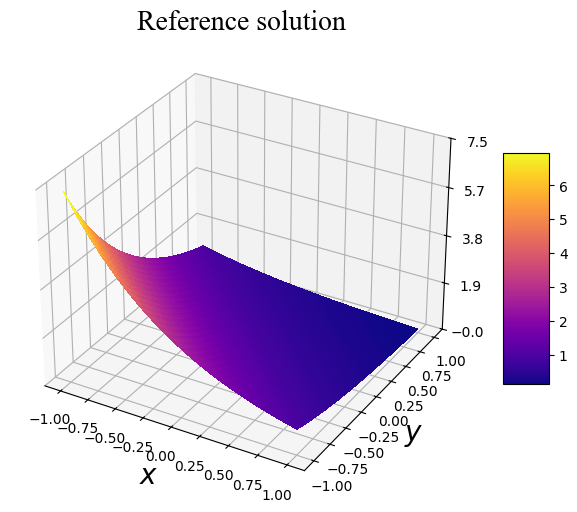

In [ ]:
font_format = {"family": "Times New Roman", "size": 20}

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(1, 1, 1, projection="3d")
surf1 = ax1.plot_surface(X, Y, avg_f, cmap="plasma", linewidth=0, antialiased=False)
ax1.set_xlabel(r"$x$", font_format)
ax1.set_ylabel(r"$y$", font_format)
ax1.zaxis.set_major_locator(LinearLocator(5))
ax1.zaxis.set_major_formatter("{x:.01f}")
ax1.set_title("Reference solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
fig.colorbar(surf1, shrink=0.5, aspect=5)

plt.show()

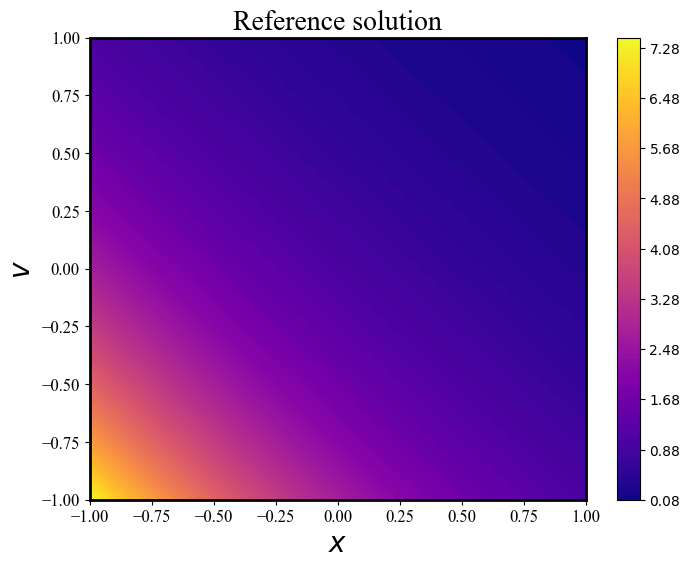

In [ ]:
font_format = {"family": "Times New Roman", "size": 20}

plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
plt.contourf(X, Y, avg_f, 100, cmap="plasma")
# font size and type
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar()
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

plt.show()
plt.close()

In [ ]:
# np.savez(
#     f"../data/rte2d_ex5_ref_{kn:.1e}.npz",
#     mesh_x=mesh_x,
#     mesh_y=mesh_y,
#     rho=avg_f,
# )